In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from utils import *

In [2]:
# Discount Rates
yields_df = pd.read_csv('data/rates.csv', usecols = ['date', 'yield'], parse_dates=['date'], dayfirst=True)
rates = Rates(data=yields_df)

# Spreads
spread_map = {"A": 0.02, "BBB": 0.03, "BB": 0.04, "B": 0.05, "CCC": 0.06}

In [3]:
issuers_df = data = pd.read_csv('data/issuers_hvb.csv', dtype={'id': 'str'}, usecols=['id', 'sector', 'rating'])
issuers = Issuers(issuers_df)

In [ ]:
bond_data = pd.read_csv('data/bonds_hvb.csv', usecols = ['id','issuer_id','notional','recovery'], dtype={'id': 'str', 'issuer_id': 'str'})
cashflows = pd.read_csv('data/cashflows_hvb.csv', parse_dates=['date'], date_format='%Y/%m').set_index('date')
cashflow_table = cashflows.resample('YE').sum().reset_index()

bonds = Bonds(
    data = bond_data,
    cashflow_table=cashflow_table,
    issuers=issuers
)

In [5]:
# Economy and Sector correlations
rho_e = .1
rho_s = np.array([.2, .3])

# Transition matrix
rating_labels = ['A', 'BBB', 'BB', 'B', 'CCC', 'Default']
transition_matrix = TransitionMatrix(
    tmatrix = np.array([
    [0.85, 0.05, 0.04, 0.03, 0.02, 0.01],
    [0.05, 0.81, 0.05, 0.04, 0.03, 0.02],
    [0.00, 0.05, 0.83, 0.05, 0.04, 0.03],
    [0.00, 0.00, 0.05, 0.86, 0.05, 0.04],
    [0.00, 0.00, 0.00, 0.05, 0.90, 0.05],
    [0.00, 0.00, 0.00, 0.00, 0.00, 1.00]
    ]),
    labels = rating_labels
)

# Model Object
cr_model = CreditRiskModel(
    issuers = issuers,
    rho_e = rho_e,
    rho_s = rho_s,
    transition_matrix = transition_matrix
)

# Run Simulation
np.random.seed(42)
n_sim = 250
n_years = 65
sim_results = cr_model.run(n_sim=n_sim, n_years=n_years)

In [6]:
# Valuation Date
val_date = pd.to_datetime('28-02-2025', dayfirst=True)

# Allocation
allocation = 400e06

# Simulated PVs
bond_sim_pv = bonds.sim_pv(
    allocation=allocation,
    val_date=val_date,
    rates=rates,
    spread_map=spread_map,
    sim_results=sim_results
)

# Simulated Cashflows
bond_sim_cashflows = bonds.sim_cashflows(
    allocation=allocation,
    val_date=val_date,
    rates=rates,
    spread_map=spread_map,
    sim_results=sim_results
)

# Bond sim object
bond_sim = bonds.run_sim(
    allocation=allocation,
    val_date=val_date,
    rates=rates,
    spread_map=spread_map,
    sim_results=sim_results
)


<Axes: xlabel='date', ylabel='cashflow'>

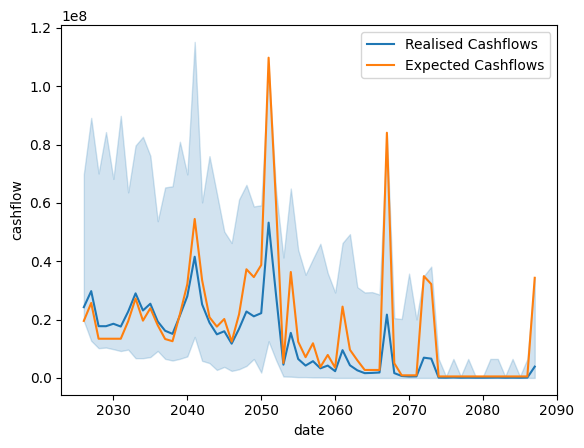

In [15]:
## plot
df = bond_sim
cf_melt = bonds.expected_cashflows(allocation, val_date, rates, spread_map).melt(ignore_index=False, var_name='bond_id', value_name='cashflow').reset_index().groupby(['date']).sum().reset_index().drop(columns='bond_id')

sns.lineplot(data = df, x = 'date', y = 'cashflow', errorbar=('pi', 100), label = 'Realised Cashflows')
sns.lineplot(data = cf_melt, x = 'date', y = 'cashflow', errorbar=('pi', 100), label = 'Expected Cashflows')

In [16]:
# Liabilities
liabilities_df = pd.read_csv('data/liabs.csv', usecols = ['date', 'cashflow'], parse_dates=['date'], dayfirst=True)
liabilities = Liabilities(data = liabilities_df)

In [17]:
portfolio = Portfolio(
    asset_list = [bonds],
    allocations = [400e06]
)

portfolio.run_sim(
    val_date=val_date,
    rates=rates,
    spread_map=spread_map,
    sim_results=sim_results
)

,date,scenario,cashflow,pv
0,2025-12-31,0,1.954974e+07,3.945440e+08
1,2025-12-31,1,3.088829e+07,3.619970e+08
2,2025-12-31,2,1.954974e+07,3.990777e+08
3,2025-12-31,3,1.954974e+07,3.917167e+08
4,2025-12-31,4,1.954974e+07,4.028716e+08
...,...,...,...,...
15495,2086-12-31,245,0.000000e+00,0.000000e+00
15496,2086-12-31,246,0.000000e+00,0.000000e+00
15497,2086-12-31,247,0.000000e+00,0.000000e+00
15498,2086-12-31,248,3.432793e+07,0.000000e+00


<Axes: xlabel='date', ylabel='assets'>

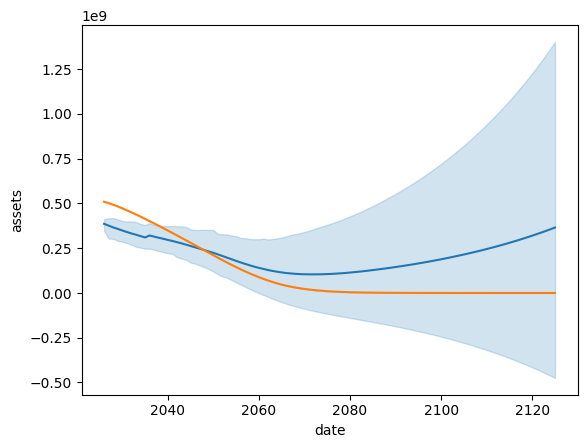

In [24]:
# Inputs
val_date = pd.to_datetime('28-02-2025', dayfirst = True)

gaap_int = 0.0201
mortality_buffer = 12.8078e06
asset_buffer = np.array([
    12.5e06, 12_987_500, 13_494_013, 14_020_279, 14_567_070, 15_135_186,
    15_725_458, 16_338_751, 16_975_962, 17_638_024, 18_325_907, 18e06
])

# Assets
portfolio = Portfolio(
    asset_list = [bonds],
    allocations = [400e06]
)
cash = 0

# CDI Portfolio
cdi_fox = CDIMandate_Fox(
    liabilities=liabilities,
    assets=portfolio,
    cash=cash,
    asset_buffer=asset_buffer,
    gaap_int=gaap_int,
    mortality_buffer=mortality_buffer
)
cdi_sim_results = cdi_fox.run(val_date, rates, spread_map, sim_results)

## plot
sns.lineplot(data=cdi_sim_results.data, x = 'date', y = 'assets', errorbar = ('pi', 100))
sns.lineplot(data=cdi_sim_results.data, x = 'date', y = 'liability_pvs', errorbar = ('pi', 100))